In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gc
import os

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('./result/상위20개컬럼.csv')

In [3]:
df

,이용금액_R3M_신용체크,_2순위카드이용금액,_1순위업종_이용금액,정상입금원금_B5M,이용금액_오프라인_B0M,_2순위업종_이용금액,최대이용금액_일시불_R12M,연체입금원금_B0M,_3순위쇼핑업종_이용금액,이용건수_오프라인_R6M,...,_3순위업종_이용금액,_1순위교통업종_이용금액,이용건수_신용_R12M,쇼핑_도소매_이용금액,이용금액_오프라인_R6M,청구금액_B0,청구금액_R6M,평잔_일시불_3M,잔액_일시불_B0M,Segment
0,196,0,1928,9205,4043,1408,4906,8104,0,54,...,672,200,165,0,11097,12226,88693,1791,998,D
1,13475,0,2158,2546,3980,2083,10407,826,315,95,...,1659,1215,204,645,18638,5834,16861,3761,2565,E
2,23988,0,16924,16949,4524,1539,10112,9364,924,76,...,1362,1362,148,1038,29192,21866,165221,6796,5312,C
3,3904,0,2405,8418,3975,2284,3075,10923,0,39,...,774,208,105,0,18056,16356,127371,772,730,D
4,1190,0,0,0,0,0,62,0,0,0,...,0,0,-1,0,787,0,155,0,0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,10755,0,0,0,0,0,0,19,0,0,...,0,0,0,0,0,0,0,0,0,E
2399996,27636,0,5608,21831,4676,1810,47684,3756,346,57,...,1547,632,219,1496,60373,14402,99849,9424,3351,D
2399997,23187,0,3634,3269,4516,2315,10212,1703,305,69,...,2302,1925,170,0,32036,5731,41073,2998,2524,C
2399998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E


In [5]:
# 예시: Segment 컬럼이 A~E 문자 등급으로 되어 있을 경우
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Segment 라벨 인코딩
le = LabelEncoder()
df['Segment'] = le.fit_transform(df['Segment'])

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 예시: df = pd.read_csv("your_data.csv")
# Segment 컬럼은 이미 숫자형(라벨 인코딩) 되어 있다고 가정

# 수치형 변수 상관계수 계산
corr_matrix = df.select_dtypes(include='number').corr()


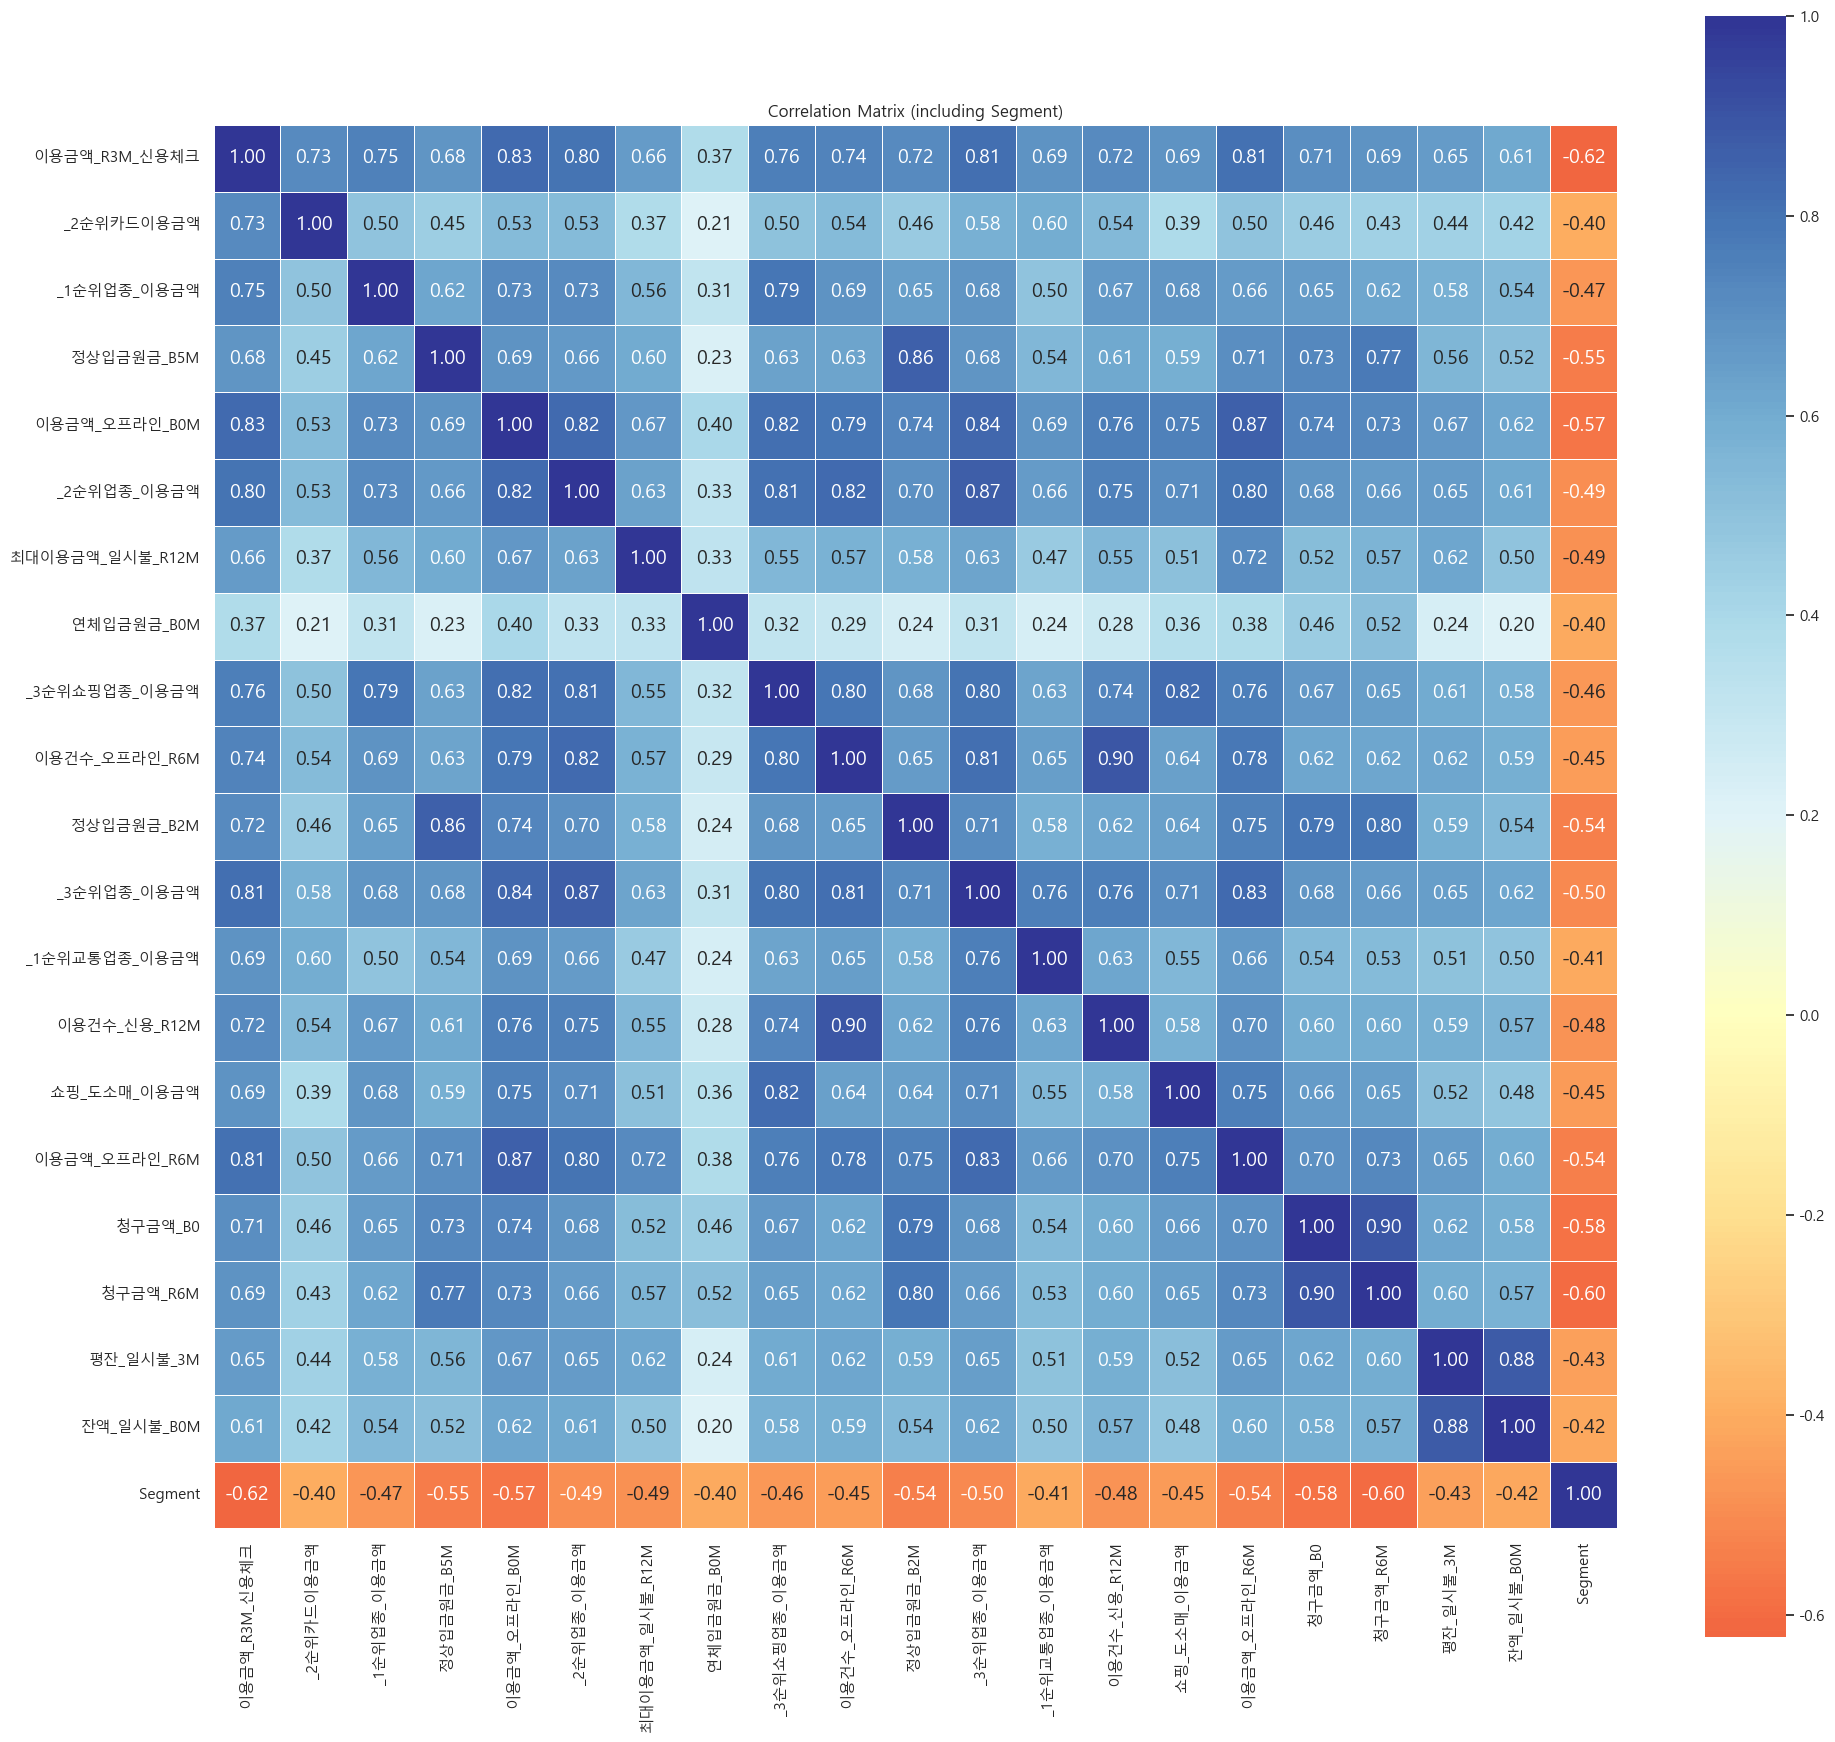

In [13]:
# 히트맵 그리기
plt.figure(figsize=(20, 18))
sns.heatmap(
    corr_matrix,
    annot=True,         # 숫자 표시
    fmt=".2f",          # 소수점 두 자리
    cmap='RdYlBu',      # 색상 (원하시면 coolwarm 등 변경 가능)
    center=0,           # 0을 가운데 기준
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix (including Segment)")
plt.tight_layout()
plt.show()

In [14]:
df_all = pd.read_csv('./corr/모든_상관계수_결측치_제거.csv')
df_all

,Variable,Correlation
0,이용금액_R3M_신용체크,-6.228267e-01
1,청구금액_R6M,-5.979035e-01
2,청구금액_R3M,-5.906781e-01
3,이용금액_R3M_신용,-5.890316e-01
4,청구금액_B0,-5.779884e-01
...,...,...
1492,컨택건수_이용유도_인터넷_B0M,2.260987e-03
1493,컨택건수_CA_청구서_B0M,1.259665e-03
1494,컨택건수_보험_TM_B0M,-9.574610e-04
1495,컨택건수_CA_TM_R6M,-3.480850e-04


In [20]:
filtered_df = df_all[df_all["Correlation"].abs() >= 0.4]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
...,...,...
1028,이용건수_일시불_B0M,-0.429503
1029,이용건수_일시불_R6M,-0.429096
1030,이용건수_일시불_R3M,-0.426715
1031,_1순위교통업종_이용금액,-0.408528


In [21]:
top_20 = filtered_df.head(20)

In [23]:
top_20

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
5,_1순위카드이용금액,-0.573870
6,평잔_일시불_6M,-0.447967
7,월중평잔_일시불_B0M,-0.444621
8,월중평잔_일시불,-0.441527
9,평잔_일시불_3M,-0.434514


C:\Users\COTTA\AppData\Local\Temp\ipykernel_19976\3786963188.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


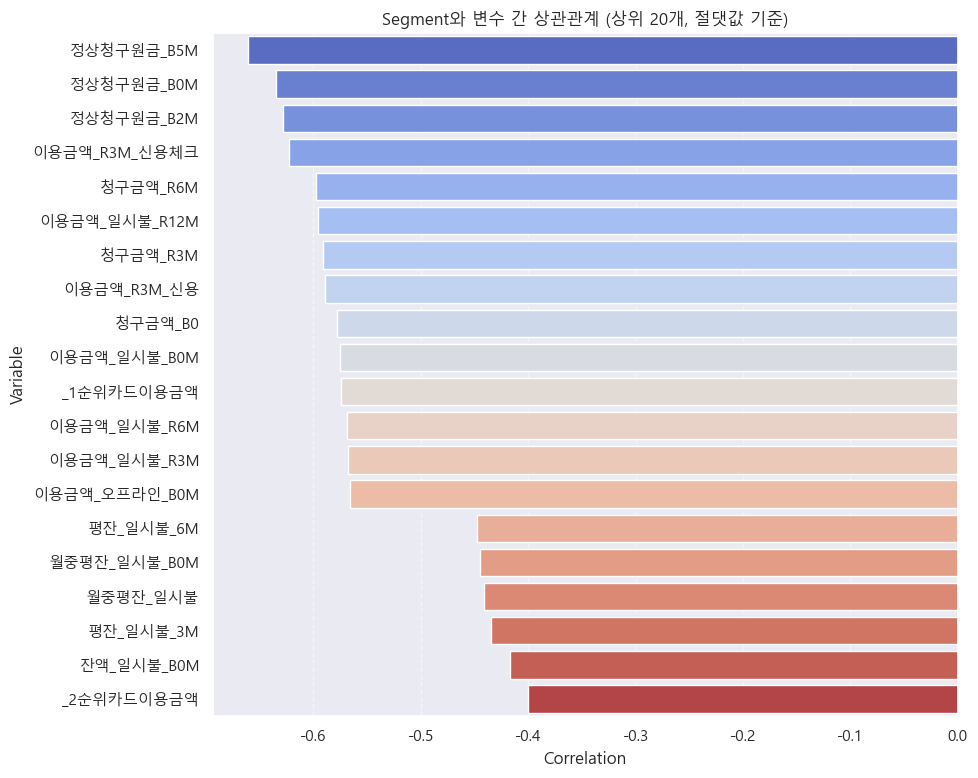

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 절댓값 기준 내림차순 정렬
top_20_sorted = top_20.reindex(top_20['Correlation'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
sns.barplot(
    x="Correlation", 
    y="Variable", 
    data=top_20_sorted, 
    palette="coolwarm"
)
plt.title("Segment와 변수 간 상관관계 (상위 20개, 절댓값 기준)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()